# Transit window-label sanity check

Visual check of the Phase-1 three-state window labels (`labels/qc/transit_window_labels_w256.parquet`): a `label=1` window must contain the shaded predicted in-transit interval, and a quarantine window must sit inside the buffer band adjacent to a transit without touching it. Ephemerides come from `labels/qc/toi_nasa.csv` (P, T0, duration; BTJD).

In [1]:
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
while not (root / "CLAUDE.md").exists():
    root = root.parent
sys.path.insert(0, str(root / "src" / "qc"))
from transit_window_coverage import _median_duration, load_ephemerides
from build_transit_window_labels import NEAR_FACTOR, index_npz_by_segment, replay_segment

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("sanity")
labels = pd.read_parquet(root / "labels" / "qc" / "transit_window_labels_w256.parquet")
eph = load_ephemerides(root / "labels" / "qc" / "toi_nasa.csv", logger)
median_dur = _median_duration(eph)
labels["label"].value_counts()

INFO:sanity:ephemerides: 6625 whitelisted TOI rows over 6351 TICs (finite P+T0)


label
 0    76514
 1    10152
-1     9290
Name: count, dtype: int64

One scandir pass indexes the transit stars' sequence files so each plot cell can load a segment without globbing the 416k-file directory.

In [2]:
transit_tics = set(labels["tic_id"].unique())
npz_index = index_npz_by_segment(root / "processed" / "sequences", transit_tics, logger)
pd.crosstab(labels["label"], labels["reason"])

INFO:sanity:indexed 5903 npz across 5903 segments for 813 transit TICs


reason,,near_transit,unfoldable
label,,,
-1,0,3994,5296
0,76514,0,0
1,10152,0,0


The plot helper is shared by the positive and quarantine cells below. Dark band = predicted in-transit interval (half-width 0.5 duration), light band = the quarantine buffer (NEAR_FACTOR durations from mid-transit).

In [3]:
def plot_window(row):
    """
    Plot one packed 256-cadence window's MAD-normalized flux against BTJD time.
    Shades every predicted transit of the star's whitelisted TOIs inside the window's time range.
    Dark band = in-transit interval, light band = quarantine buffer around it.
    """
    key = (int(row.tic_id), int(row.sector), int(row.seg_idx))
    times, flux = replay_segment(npz_index[key][0], 256, 20.0)
    t = times[row.win_in_seg]
    f = flux[row.win_in_seg]
    plt.figure(figsize=(10, 4))
    plt.plot(t, f, linewidth=0.8)
    for P, T0, dur in eph.get(int(row.tic_id), []):
        d = dur if np.isfinite(dur) else median_dur
        k0 = int(np.floor((t.min() - T0) / P)) - 1
        k1 = int(np.ceil((t.max() - T0) / P)) + 1
        for k in range(k0, k1 + 1):
            mid = T0 + k * P
            plt.axvspan(mid - NEAR_FACTOR * d, mid + NEAR_FACTOR * d, color="orange", alpha=0.15)
            plt.axvspan(mid - 0.5 * d, mid + 0.5 * d, color="crimson", alpha=0.3)
    plt.xlim(t.min(), t.max())
    plt.xlabel("time (BTJD, d)")
    plt.ylabel("flux (MAD units)")
    plt.title(f"TIC {row.tic_id} | {row.seg_id} win {row.win_in_seg} | label {row.label} | in-transit cadences {row.n_intransit_cad}")
    plt.show()

## Random in-transit window (`label = 1`)

The dark band must overlap the plotted window; the dip may still be weak (Task C: these are shallow, hours-long events).

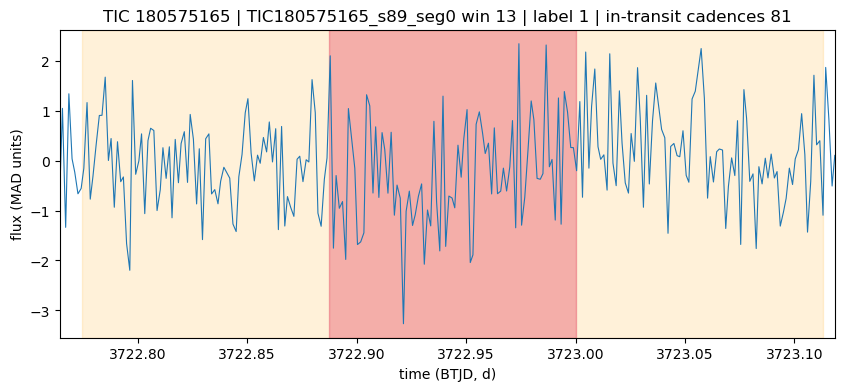

In [4]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0)  # uncomment for a reproducible sample
pos = labels[labels["label"] == 1]
plot_window(pos.iloc[rng.integers(len(pos))])

## Random quarantine window (`reason = near_transit`)

The light buffer band must reach into the window while the dark in-transit band stays outside it. Unfoldable-star quarantine windows are skipped here since they have no ephemeris to shade.

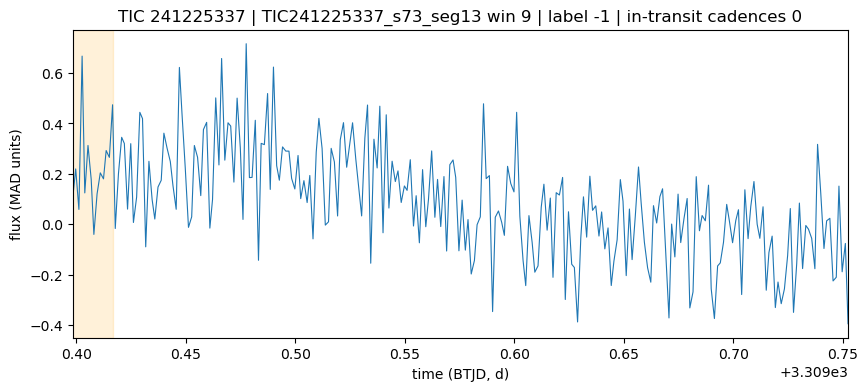

In [5]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0)  # uncomment for a reproducible sample
quar = labels[labels["reason"].str.startswith("near_transit")]
plot_window(quar.iloc[rng.integers(len(quar))])

## Random positive star's full segment

Context view: the whole contiguous segment with its predicted transits, showing how the 256-cadence windows slice the events.

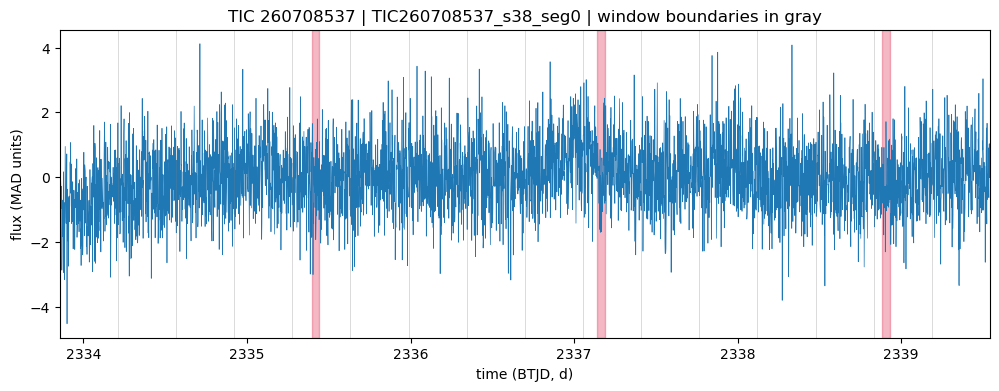

In [6]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0)  # uncomment for a reproducible sample
seg_ids = pos["seg_id"].unique()
seg_rows = labels[labels["seg_id"] == seg_ids[rng.integers(len(seg_ids))]]
first = seg_rows.iloc[0]
key = (int(first.tic_id), int(first.sector), int(first.seg_idx))
times, flux = replay_segment(npz_index[key][0], 256, 20.0)
plt.figure(figsize=(12, 4))
plt.plot(times.reshape(-1), flux.reshape(-1), linewidth=0.5)
for P, T0, dur in eph.get(int(first.tic_id), []):
    d = dur if np.isfinite(dur) else median_dur
    for k in range(int(np.floor((times.min() - T0) / P)) - 1, int(np.ceil((times.max() - T0) / P)) + 2):
        plt.axvspan(T0 + k * P - 0.5 * d, T0 + k * P + 0.5 * d, color="crimson", alpha=0.3)
for t_win in times:
    plt.axvline(t_win[0], color="gray", linewidth=0.4, alpha=0.5)
plt.xlim(times.min(), times.max())
plt.xlabel("time (BTJD, d)")
plt.ylabel("flux (MAD units)")
plt.title(f"TIC {first.tic_id} | {first.seg_id} | window boundaries in gray")
plt.show()